라이브러리

In [ ]:
# 목표: 운동 하는 동안 얼마나 칼로리를 소모하는가? 예측
# 데이터: 개인정보 데이터
 #ID,Gender,Age,Weight(lb),키는 합치고[Height(Feet),Height(Remainder_Inches)],Weight_Status
  #7개
# 운동강도 및 환경 데이터
 #Exercise_Duration(분당?), Body_Temperature(F)화씨,BPM
  #3개

  #타겟: 칼로리
  # 인코딩 원핫?

  # 학습 데이터 6000개
  # 테스트 데이터 1500개

  # 평가지표 RMSE Root Mean Square Error MSE에 넘파이 루트


In [13]:
# 차트 작성 시 한글 깨짐 방지를 위한 koreanize-matplotlib 설치
!pip install koreanize-matplotlib
#캣부스트
!pip install catboost
#Optuna
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 10.9 MB/s eta 0:00:00


In [14]:
import numpy as np # 넘파이
import pandas as pd # 판다스
import seaborn as sb # 씨본
import matplotlib.pyplot as plt # 맷플롯립
import koreanize_matplotlib # 한글 보존

from sklearn.model_selection import train_test_split, KFold, GridSearchCV # 데이터분할
from xgboost import XGBRegressor, plot_importance # XGB
from catboost import CatBoostRegressor # CB
from lightgbm import LGBMRegressor, plot_importance # LG
from sklearn.metrics import r2_score, mean_squared_error # 평가지표 -> 나중에 루트씌움
import warnings
warnings.filterwarnings('ignore')

데이터 불러오기

In [15]:
# 데이터 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
#데이터 확인
train.head()
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        7500 non-null   object 
 1   Exercise_Duration         7500 non-null   float64
 2   Body_Temperature(F)       7500 non-null   float64
 3   BPM                       7500 non-null   float64
 4   Height(Feet)              7500 non-null   float64
 5   Height(Remainder_Inches)  7500 non-null   float64
 6   Weight(lb)                7500 non-null   float64
 7   Weight_Status             7500 non-null   object 
 8   Gender                    7500 non-null   object 
 9   Age                       7500 non-null   int64  
 10  Calories_Burned           7500 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 644.7+ KB


,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Age,Calories_Burned
count,7500.0000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,15.5012,104.033573,95.498133,5.248800,5.717600,165.361187,42.636000,89.373467
std,8.3553,1.412845,9.587331,0.556663,3.497315,33.308136,16.883188,62.817086
min,1.0000,98.800000,69.000000,4.000000,0.000000,79.400000,20.000000,1.000000
25%,8.0000,103.300000,88.000000,5.000000,3.000000,138.900000,28.000000,35.000000
50%,15.0000,104.400000,95.000000,5.000000,6.000000,163.100000,39.000000,77.000000
75%,23.0000,105.100000,103.000000,6.000000,9.000000,191.800000,56.000000,138.000000
max,30.0000,106.700000,128.000000,7.000000,12.000000,291.000000,79.000000,300.000000


데이터 정제, 결측치 확인, 데이터 타입 확인

In [ ]:
# 결측치(NaN) 확인

def check_missing_and_dtypes(df, name="Dataset"):
    print(f"\n{name} Info:")
    print("-" * 50)
    nulls = df.isnull().sum()
    dtypes = df.dtypes
    summary = pd.DataFrame({
        "Data Type": dtypes,
        "Missing Values": nulls,
        "Missing (%)": (nulls / len(df)) * 100
    })
    print(summary)
    return summary


train_info = check_missing_and_dtypes(train, "Train Set")
test_info = check_missing_and_dtypes(test, "Test Set")


Train Set Info:
--------------------------------------------------
                         Data Type  Missing Values  Missing (%)
ID                          object               0          0.0
Exercise_Duration          float64               0          0.0
Body_Temperature(F)        float64               0          0.0
BPM                        float64               0          0.0
Height(Feet)               float64               0          0.0
Height(Remainder_Inches)   float64               0          0.0
Weight(lb)                 float64               0          0.0
Weight_Status               object               0          0.0
Gender                      object               0          0.0
Age                          int64               0          0.0
Calories_Burned            float64               0          0.0

Test Set Info:
--------------------------------------------------
                         Data Type  Missing Values  Missing (%)
ID                          objec

EDA 및 시각화

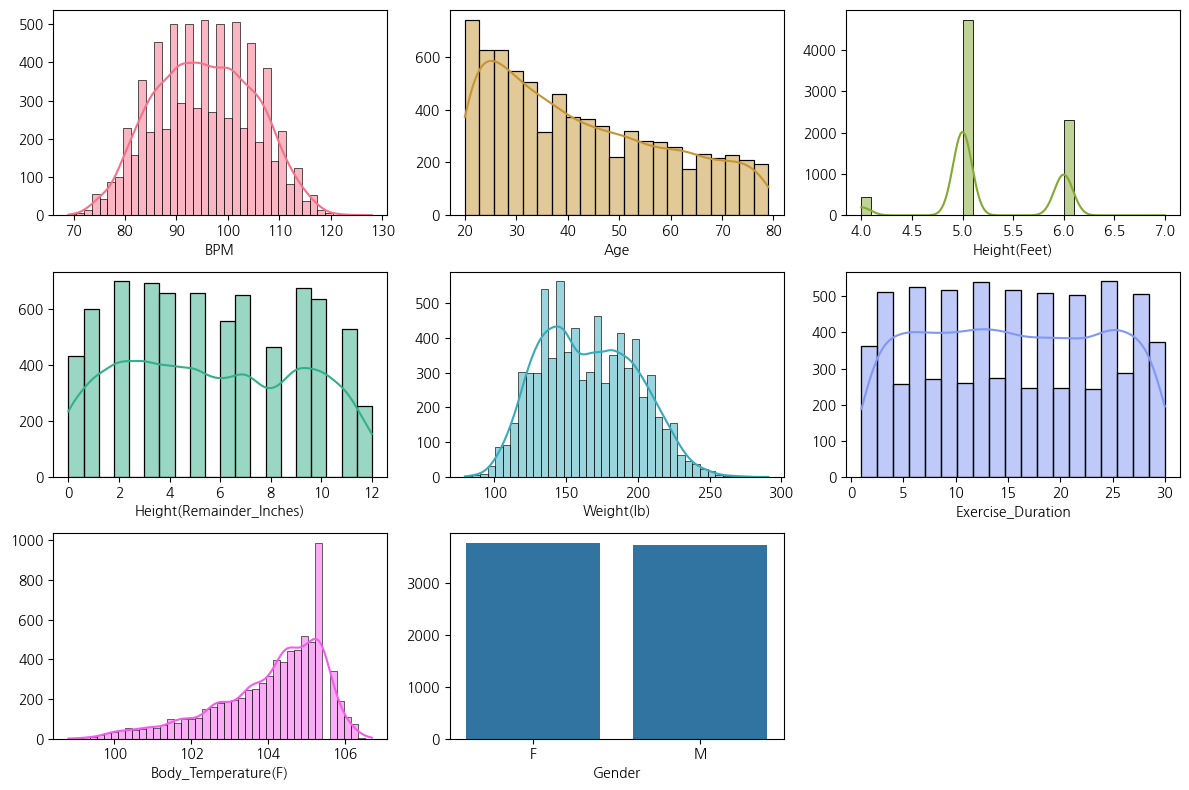

In [ ]:
# 수치형 데이터 분포 비율 KDE (Raw 데이터 7개)

col = ["BPM","Age", "Height(Feet)", "Height(Remainder_Inches)", "Weight(lb)", "Exercise_Duration", "Body_Temperature(F)"]
colors = sb.color_palette("husl", len(col))

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()


for i in range(len(col)):
    sb.histplot(train[col[i]], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_ylabel("")


sb.countplot(x='Gender', data=train, ax=axes[len(col)])
axes[len(col)].set_ylabel("")


for j in range(len(col) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
"""
피처간 스케일 차이

"""

'\n피처간 스케일 차이\n\n'

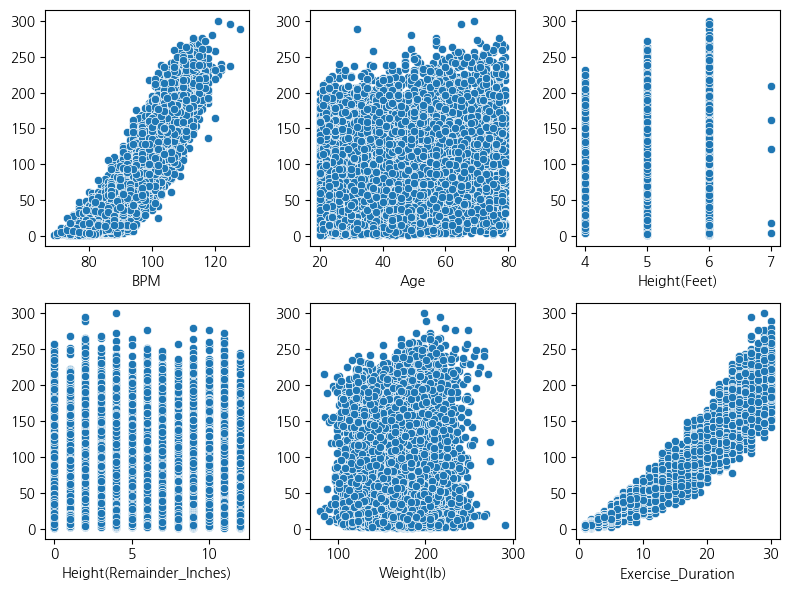

In [ ]:
# 수치형 데이터 관계도 (Raw 데이터 7개)

col = ["BPM","Age", "Height(Feet)", "Height(Remainder_Inches)", "Weight(lb)", "Exercise_Duration", "Body_Temperature(F)"]


fig, axes = plt.subplots(2,3, figsize = (8, 6) )

axes = axes.flatten()

for i in range(len(axes)):
    if i < len(col):
        sb.scatterplot(x = col[i], y = 'Calories_Burned', data = train, ax = axes[i])
        axes[i].set_ylabel("")
    else:
        fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,Calories_Burned,Age_Grp
0,TRAIN_0000,26.0,105.6,107.0,5.0,9.0,154.3,Normal Weight,F,45,166.0,40대
1,TRAIN_0001,7.0,103.3,88.0,6.0,6.0,224.9,Overweight,M,50,33.0,50대
2,TRAIN_0002,7.0,103.3,86.0,6.0,3.0,218.3,Overweight,M,29,23.0,20대
3,TRAIN_0003,17.0,104.0,99.0,5.0,6.0,147.7,Normal Weight,F,33,91.0,30대
4,TRAIN_0004,9.0,102.7,88.0,5.0,10.0,169.8,Normal Weight,M,38,32.0,30대


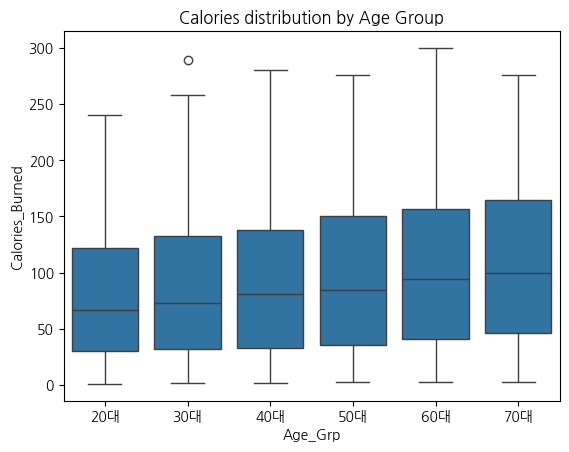

In [ ]:
# 수치형 데이터 그룹화
bins = [20, 30, 40, 50, 60, 70, 81]
labels = ["20대", "30대", "40대", "50대", "60대", "70대"]
train["Age_Grp"] = pd.cut(train["Age"], bins=bins, labels=labels, right=False)

display(train.head())

# 범주형으로 변환 후 시각화
sb.boxplot(x='Age_Grp', y='Calories_Burned', data=train)
plt.title('Calories distribution by Age Group')
plt.show()

In [ ]:
# bins = [20, 35, 55, 80]
# labels = ['Young Adults', 'Middle Age', 'Senior']

# train['Age_Grp'] = pd.cut(train['Age'], bins = bins, labels = labels, right = True, include_lowest = True)
# test['Age_Grp'] = pd.cut(test['Age'], bins = bins, labels = labels, right = True, include_lowest = True)

# sb.boxplot(x='Age_Grp', y='Calories_burned', data=train)
# plt.title('Calories distribution by Age Group')
# plt.show()

In [ ]:
"""
박스 플롯에 따르면,
연소되는 칼로리의 양은 젊은 성인에서 노인으로 증가하는 경향이 있습니다.
다음으로, 성별과 운동 기간에 따라 칼로리 소비가 어떻게 달라지는지 살펴봅시다.

"""

'\n박스 플롯에 따르면, \n연소되는 칼로리의 양은 젊은 성인에서 노인으로 증가하는 경향이 있습니다.\n다음으로, 성별과 운동 기간에 따라 칼로리 소비가 어떻게 달라지는지 살펴봅시다.\n\n'

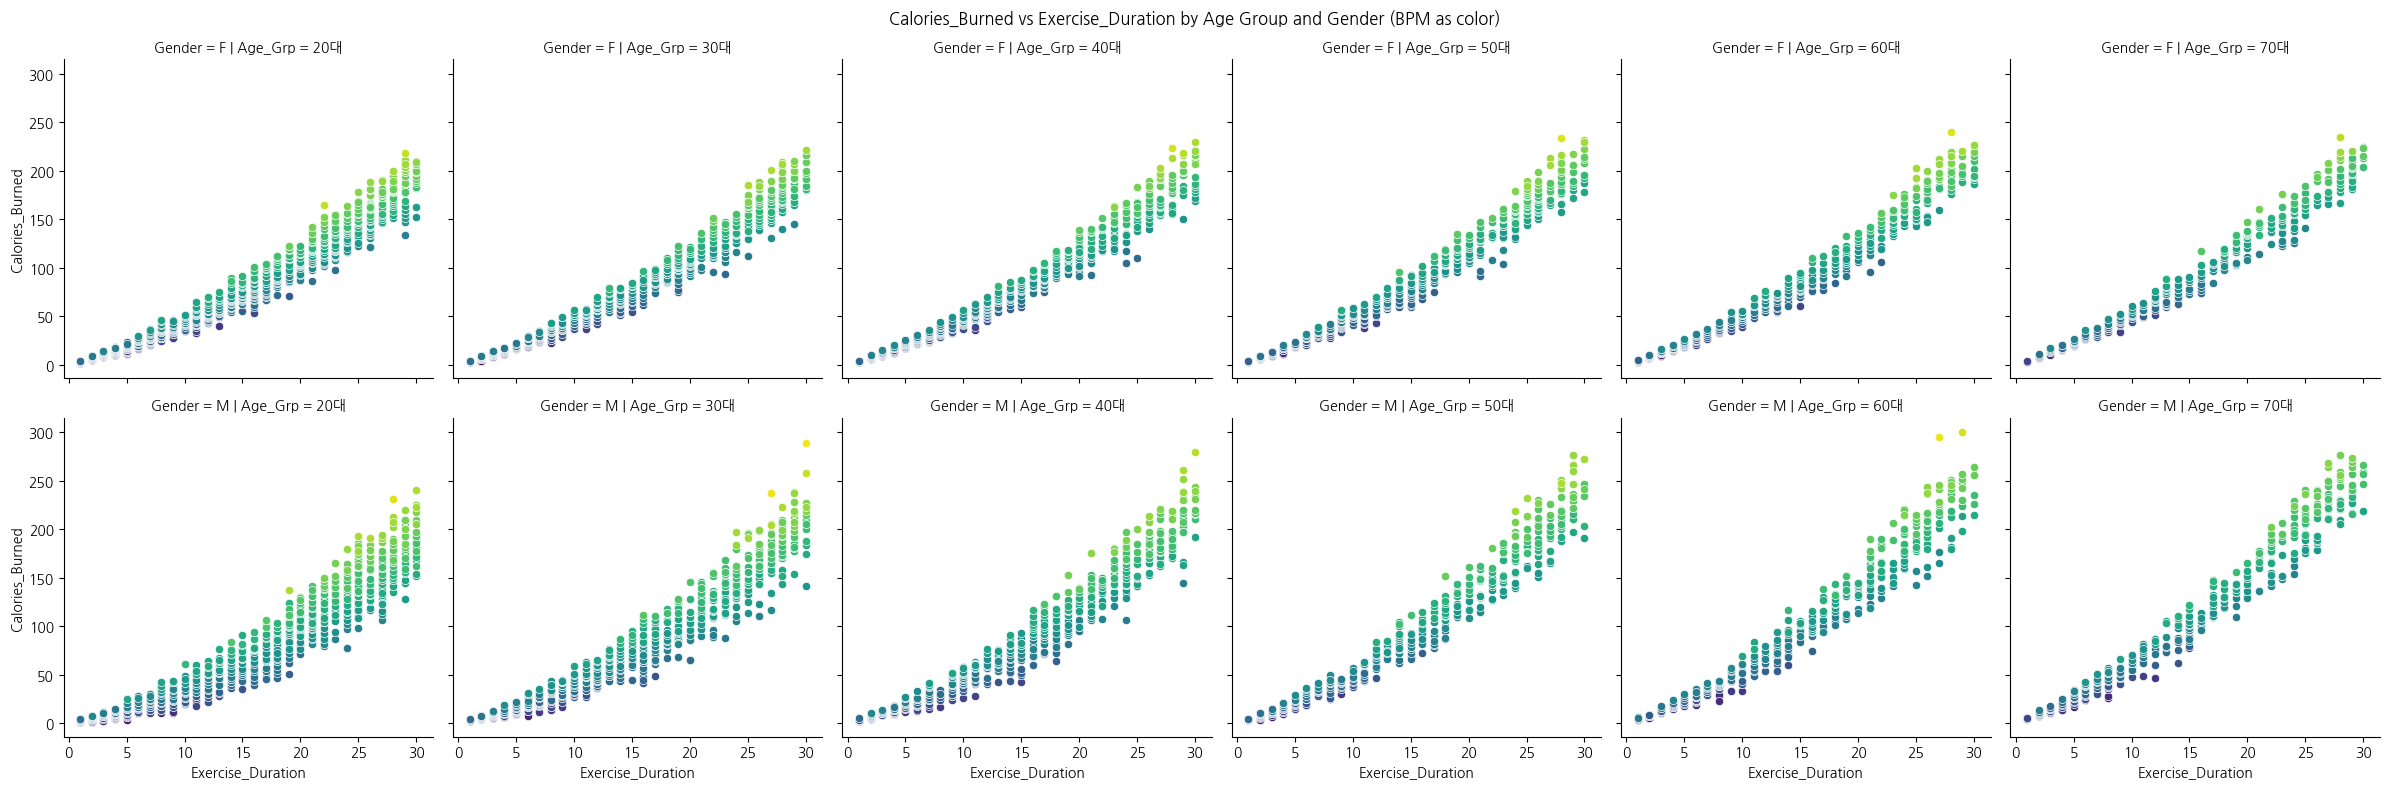

In [ ]:
"""
남여 모두 운동기간에 비례하여 칼로리 소모량 증가
"""

g = sb.FacetGrid(train, col="Age_Grp", row="Gender", hue="BPM", palette="viridis", height=4)
g.map(sb.scatterplot, "Exercise_Duration", "Calories_Burned")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Calories_Burned vs Exercise_Duration by Age Group and Gender (BPM as color)')

plt.tight_layout()
plt.show()

특성 공학

In [ ]:
"""
다항식 말고
"""

In [ ]:
# 파생변수

def add_features(df) -> pd.DataFrame:
    d = df.copy()
    # ---------- 0) 타입 ----------
    num_cols = [
        "Exercise_Duration",
        "Body_Temperature(F)",
        "BPM",
        "Height(Feet)",
        "Height(Remainder_Inches)",
        "Weight(lb)",
        "Age",
    ]
    for c in num_cols:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    # ---------- 1) 단위 변환 (키, 몸무게, 체온) ----------

    # 키
    d["height_in"] = d["Height(Feet)"] * 12 + d["Height(Remainder_Inches)"]
    d["height_cm"] = d["height_in"] * 2.54
    d["height_m"] = d["height_cm"] / 100.0

    # 몸무게
    d["weight_kg"] = d["Weight(lb)"] * 0.45359237

    # 체온
    d["temp_c"] = (d["Body_Temperature(F)"] - 32) * (5 / 9)

    # ---------- 2) 성별/대사 ----------
    # BMI
    d["bmi"] = d["weight_kg"] / (d["height_m"] ** 2)

    # Gender 인코딩 (M=1, F=0; 그 외는 NaN)
    d["Gender"] = (
        d["Gender"].astype(str).str.strip().str.upper()
        .map({"M": 1, "MALE": 1, "F": 0, "FEMALE": 0})
    )

# ====== 신체 정보 관련 ======
# 1. BMR - 기초대사량: 해리스 - 베네딕트 계산식
    d["bmr"] = np.where(
        d["Gender"] == 1,
        66.47 + (13.75 * d["weight_kg"]) + (5.0 * d["height_cm"]) - (6.76 * d["Age"]),  # 남자
        np.where(
            d["Gender"] == 0,
            655.1 + (9.56 * d["weight_kg"]) + (1.85 * d["height_cm"]) - (4.68 * d["Age"]),  # 여자
            np.nan
        )
    )

# ====== 운동 관련 ======
# 2. MHR: 최대 심박수 계산
    d["mhr"] = 220 - d["Age"]

# 3. activity_intensity: 활동 강도 계산
    d["activity_intensity"] = get_activity_intensity_by_age(d["BPM"], d["Age"])

# 4. 심박 예비력 비율 계산 Heart Rate Reserve
    HR_REST = 60  # 안정 시 심박수 계산에 사용되는 기본 심박수
    d["hrr"] = d["mhr"] - HR_REST  # 내가 낼 수 있는 최대 심박 중에서 지금 얼마나 쓰고 있는지 나타내는 지표
    d["hrr_ratio"] = (d["BPM"] - HR_REST) / d["hrr"]
# 강도가 높을수록 비율이 높아짐 -> 퍼센티지!! 1에 가까울수록 높은 강도

# 5. 열부하지표 (운동 시 체온 상승은 대사를 증가시킴)
# 체온이 1도씨 상승하면 대사율 약 10-13% 증가
    d["thermal_load"] = (d["temp_c"] - 37) * d["Exercise_Duration"]

# ====== 신체와 운동 합친 것 관련 ======

# 6. 체중 보정 심박 부하
    d["relative_workload"] = (d["BPM"] * d["weight_kg"] * d["Exercise_Duration"]) / d["Age"]

# 7. 심박 스트레스 비율 지수
    d["hb_stress"] = d["BPM"] / d["mhr"]

# 8. 대사 스트레스 지수
    d["metabolic_stress"] = d["BPM"] * d["Exercise_Duration"]
    return d


def get_activity_intensity_by_age(bpm_series, age_series):
    """
    연령별 목표 심박수 표 기반으로 Light/Moderate/High 분류

Light: bpm < low_cut
Moderate: low_cut <= bpm < high_cut
High: bpm >= high_cut
"""

    # 표(이미지) 기반 앵커 포인트
    ages = np.array([15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,95], dtype=float)

    # 저강도 경계(표의 '<' 값)
    low_cut_points = np.array([126,124,122,120,117,115,113,111,109,107,105,102,100,98,96,92], dtype=float)

    # 중강도 상한(표의 '중강도' 범위의 상단 값)
    high_cut_points = np.array([150,147,145,142,139,137,134,132,129,127,124,122,119,117,114,109], dtype=float)

    age = pd.to_numeric(age_series, errors="coerce").astype(float).to_numpy()
    bpm = pd.to_numeric(bpm_series, errors="coerce").astype(float).to_numpy()

    # 나이에 맞춰 컷을 선형 보간 (15 미만/95 초과는 끝값으로 고정)
    low_cut  = np.interp(age, ages, low_cut_points)
    high_cut = np.interp(age, ages, high_cut_points)

    out = np.where(bpm < low_cut, "Light",
          np.where(bpm < high_cut, "Moderate", "High"))


    return out


train = add_features(train)
test = add_features(test)

display(train.head())

,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,...,bmi,bmr,mhr,activity_intensity,hrr,hrr_ratio,thermal_load,relative_workload,hb_stress,metabolic_stress
0,TRAIN_0000,26.0,105.6,107.0,5.0,9.0,154.3,Normal Weight,0,45,...,22.785893,1437.828734,175,Light,115,0.408696,101.111111,4326.894224,0.611429,2782.0
1,TRAIN_0001,7.0,103.3,88.0,6.0,6.0,224.9,Overweight,1,50,...,25.989538,2121.747705,170,Light,110,0.254545,18.277778,1256.799224,0.517647,616.0
2,TRAIN_0002,7.0,103.3,86.0,6.0,3.0,218.3,Overweight,1,29,...,27.285349,2184.444198,191,Light,131,0.198473,18.277778,2055.502312,0.450262,602.0
3,TRAIN_0003,17.0,104.0,99.0,5.0,6.0,147.7,Normal Weight,0,33,...,23.839159,1451.271870,187,Light,127,0.307087,51.000000,3416.775245,0.529412,1683.0
4,TRAIN_0004,9.0,102.7,88.0,5.0,10.0,169.8,Normal Weight,1,38,...,24.363513,1757.614786,182,Light,122,0.229508,20.500000,1605.258623,0.483516,792.0


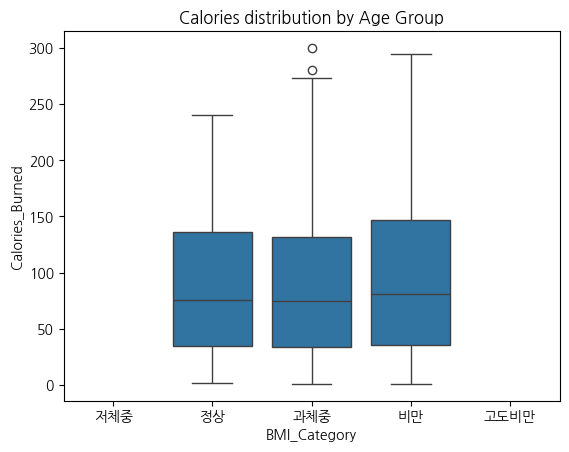

In [ ]:
# BMI 범주
bins = [0, 18.5, 23, 25, 30, 100]
labels = ["저체중", "정상", "과체중", "비만", "고도비만"]
train['BMI_Category'] = pd.cut(train['bmi'], bins=bins, labels=labels, right=False)

# 범주형으로 변환 후 시각화
sb.boxplot(x='BMI_Category', y='Calories_Burned', data=train)
plt.title('Calories distribution by Age Group')
plt.show()

In [ ]:
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   ID                        7500 non-null   object  
 1   Exercise_Duration         7500 non-null   float64 
 2   Body_Temperature(F)       7500 non-null   float64 
 3   BPM                       7500 non-null   float64 
 4   Height(Feet)              7500 non-null   float64 
 5   Height(Remainder_Inches)  7500 non-null   float64 
 6   Weight(lb)                7500 non-null   float64 
 7   Weight_Status             7500 non-null   object  
 8   Gender                    7500 non-null   int64   
 9   Age                       7500 non-null   int64   
 10  Calories_Burned           7500 non-null   float64 
 11  Age_Grp                   7500 non-null   category
 12  height_in                 7500 non-null   float64 
 13  height_cm                 7500 non-null   float6

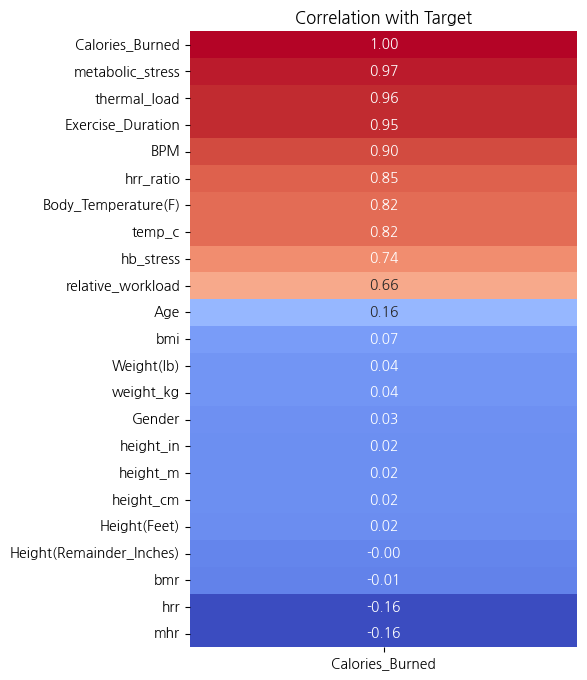

In [ ]:
# 타겟 변수와의 상관관계만 추출하여 내림차순 정렬
target_corr = train.corr(numeric_only=True)['Calories_Burned'].sort_values(ascending=False)

plt.figure(figsize=(5, 8))
sb.heatmap(target_corr.to_frame(),
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            cbar=False)
plt.title('Correlation with Target')
plt.show()

In [17]:
# language: python
# requirements: pandas, numpy, scikit-learn, lightgbm, xgboost, optuna
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import xgboost as xgb
import optuna

# 1) Load CSV
df = pd.read_csv("train.csv")  # 파일명에 맞춰 변경

# 2) Basic preprocessing and feature engineering
df = df.copy()
# Convert units
df['Weight_kg'] = df['Weight(lb)'] * 0.45359237
df['Total_inches'] = df['Height(Feet)'] * 12 + df['Height(Remainder_Inches)']
df['Height_m'] = df['Total_inches'] * 0.0254
df['Body_Temp_C'] = (df['Body_Temperature(F)'] - 32) * 5.0/9.0

# Derived features
df['BMI'] = df['Weight_kg'] / (df['Height_m'] ** 2)
df['BPM_times_Dur'] = df['BPM'] * df['Exercise_Duration']
df['Dur_per_kg'] = df['Exercise_Duration'] / (df['Weight_kg'] + 1e-6)

# Select features and target
cat_cols = ['Gender', 'Weight_Status']
num_cols = ['Exercise_Duration', 'Body_Temp_C', 'BPM',
            'Age', 'Weight_kg', 'Height_m', 'BMI',
            'BPM_times_Dur', 'Dur_per_kg']
features = num_cols + cat_cols
target = 'Calories_Burned'

X = df[features]
y = df[target]

# If you already have 6000 train and 1500 test, skip split.
# Example split to mimic 6000/1500 proportion (here using 80/20):
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1500/ (6000+1500), random_state=42
)

# 3) Preprocessing: numeric scaler + one-hot for categorical
num_pipe = Pipeline([
    ('scaler', StandardScaler())  # tree models don't require but keep for stacking/meta learner
])
cat_pipe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preproc = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
], remainder='drop')

# 4) Base learners (sklearn API wrappers)
lgb_model = lgb.LGBMRegressor(n_jobs=-1, random_state=42)
xgb_model = xgb.XGBRegressor(n_jobs=-1, random_state=42, verbosity=0)
rf_model = RandomForestRegressor(n_jobs=-1, random_state=42)

# 5) Stacking regressor (meta learner: Ridge)
stack = Pipeline([
    ('preproc', preproc),
    ('stack', StackingRegressor(
        estimators=[
            ('lgb', lgb_model),
            ('xgb', xgb_model),
            ('rf', rf_model)
        ],
        final_estimator=Ridge(),
        n_jobs=-1,
        passthrough=False
    ))
])

# 6) Utility: CV RMSE using NumPy
def cv_rmse(pipe, X, y, folds=5):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    # scoring uses neg_mean_squared_error
    mses = -cross_val_score(pipe, X, y, cv=kf,
                            scoring='neg_mean_squared_error', n_jobs=-1)
    rmses = np.sqrt(mses)
    return rmses.mean()

print("Baseline stacking CV RMSE:", cv_rmse(stack, X_train, y_train))

Baseline stacking CV RMSE: 2.084916280451556


In [18]:
# language: python
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'num_leaves': trial.suggest_int('num_leaves', 16, 256),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 200),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 10.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    pipe = Pipeline([
        ('preproc', preproc),
        ('model', lgb.LGBMRegressor(**params))
    ])
    # return CV RMSE
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mses = -cross_val_score(pipe, X_train, y_train, cv=kf,
                           scoring='neg_mean_squared_error', n_jobs=-1)
    return np.sqrt(mses).mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, n_jobs=1)

print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)


[I 2026-02-13 02:31:10,070] A new study created in memory with name: no-name-42b04e62-8d49-4852-9dc6-56d9ca0727ca
[I 2026-02-13 02:31:41,212] Trial 0 finished with value: 2.1232070460010863 and parameters: {'n_estimators': 1198, 'num_leaves': 200, 'learning_rate': 0.02557158004320251, 'min_child_samples': 89, 'reg_alpha': 4.32618827187104e-06, 'reg_lambda': 0.00023206642315394118, 'subsample': 0.680302049723812, 'colsample_bytree': 0.5605598389229933}. Best is trial 0 with value: 2.1232070460010863.
[I 2026-02-13 02:32:08,113] Trial 1 finished with value: 2.6801514690695205 and parameters: {'n_estimators': 1235, 'num_leaves': 164, 'learning_rate': 0.03318985994091438, 'min_child_samples': 172, 'reg_alpha': 0.028697834116607805, 'reg_lambda': 1.9327415061041993e-05, 'subsample': 0.7061510819054451, 'colsample_bytree': 0.8848073443194941}. Best is trial 0 with value: 2.1232070460010863.
[I 2026-02-13 02:32:21,696] Trial 2 finished with value: 15.790766821597401 and parameters: {'n_estima

Best RMSE: 1.573237405565849
Best params: {'n_estimators': 1045, 'num_leaves': 19, 'learning_rate': 0.05189623240626457, 'min_child_samples': 14, 'reg_alpha': 2.1378204018686793, 'reg_lambda': 2.860264255645073e-06, 'subsample': 0.717925940413787, 'colsample_bytree': 0.4923784802836091}


In [20]:
# language: python
best_params = study.best_params
final_pipe = Pipeline([
    ('preproc', preproc),
    ('model', lgb.LGBMRegressor(**best_params, random_state=42))
])
final_pipe.fit(X_train, y_train)
y_pred = final_pipe.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test MSE:", mse, "Test RMSE:", rmse)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000670 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1078
[LightGBM] [Info] Number of data points in the train set: 6000, number of used features: 14
[LightGBM] [Info] Start training from score 89.566667
Test MSE: 3.8821050447476355 Test RMSE: 1.9703058251823842
